# Rossmann Store Sales: Model Comparison

## 1. Comparison Framework

The models compared in this notebook were evaluated on the same forecasting target and test period:

- **Target:** Total daily sales aggregated across all Rossmann stores
- **Test period:** 2015-06-02 to 2015-07-31
- **Test size:** 60 days
- **Evaluation metrics:** MAE and RMSE
- **Validation approach:** Chronological train-test split

Because the models use the same target, holdout period, and evaluation metrics, their test performance can be compared directly.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Model Performance Results

This section collects the final test-set performance metrics from the forecasting models developed in Phase 2 and Phase 3.

All models were evaluated using the same aggregated daily sales target and the same 60-day chronological holdout period.

Lower MAE and RMSE values indicate better forecasting performance.

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA(7,0,0)",
        "SARIMA(1,0,0)x(1,0,1,7)",
        "LightGBM"
    ],
    "MAE": [
        2746028.78,
        2084717.68,
        2075114.51,
        1122513.00,
        323834.04
    ],
    "RMSE": [
        4278452.33,
        2570396.03,
        2727431.88,
        1540606.00,
        451188.96
    ]
})

model_results

,Model,MAE,RMSE
0,Naive,2746028.78,4278452.33
1,Seasonal Naive,2084717.68,2570396.03
2,"ARIMA(7,0,0)",2075114.51,2727431.88
3,"SARIMA(1,0,0)x(1,0,1,7)",1122513.00,1540606.00
4,LightGBM,323834.04,451188.96


## 3. Model Performance Ranking

The models are ranked separately based on MAE and RMSE, where a lower error receives a better rank.

A rank of 1 indicates the strongest performance for that evaluation metric.

In [31]:
# Rank models by MAE and RMSE
comparison_ranked = model_results.copy()

comparison_ranked["MAE Rank"] = comparison_ranked["MAE"].rank(
    method="min"
).astype(int)

comparison_ranked["RMSE Rank"] = comparison_ranked["RMSE"].rank(
    method="min"
).astype(int)

comparison_ranked = comparison_ranked.sort_values("MAE")

comparison_ranked

,Model,MAE,RMSE,MAE Rank,RMSE Rank
4,LightGBM,323834.04,451188.96,1,1
3,"SARIMA(1,0,0)x(1,0,1,7)",1122513.00,1540606.00,2,2
2,"ARIMA(7,0,0)",2075114.51,2727431.88,3,4
1,Seasonal Naive,2084717.68,2570396.03,4,3
0,Naive,2746028.78,4278452.33,5,5


## 4. Improvement Over the Best Classical Model

The best-performing classical model was SARIMA(1,0,0)x(1,0,1,7), which ranked second overall on both MAE and RMSE.

This section measures the percentage reduction in forecasting error achieved by LightGBM compared with the best classical model.

In [32]:
sarima_mae = model_results.loc[
    model_results["Model"] == "SARIMA(1,0,0)x(1,0,1,7)",
    "MAE"
].iloc[0]

sarima_rmse = model_results.loc[
    model_results["Model"] == "SARIMA(1,0,0)x(1,0,1,7)",
    "RMSE"
].iloc[0]

lightgbm_mae = model_results.loc[
    model_results["Model"] == "LightGBM",
    "MAE"
].iloc[0]

lightgbm_rmse = model_results.loc[
    model_results["Model"] == "LightGBM",
    "RMSE"
].iloc[0]

mae_improvement = (
    (sarima_mae - lightgbm_mae) / sarima_mae
) * 100

rmse_improvement = (
    (sarima_rmse - lightgbm_rmse) / sarima_rmse
) * 100

print(f"MAE reduction: {mae_improvement:.2f}%")
print(f"RMSE reduction: {rmse_improvement:.2f}%")

MAE reduction: 71.15%
RMSE reduction: 70.71%


### Interpretation

Compared with the best classical model, SARIMA(1,0,0)x(1,0,1,7), LightGBM reduced:

- MAE by **71.15%**
- RMSE by **70.71%**

These results indicate substantially lower forecasting error for LightGBM on the shared 60-day holdout period.

The comparison is valid because both models were evaluated on the same aggregated daily sales target, the same chronological test period, and the same evaluation metrics.

## 5. Visual Comparison of Model Performance

The following visualizations compare the forecasting error of all evaluated models.

Lower MAE and RMSE values indicate better forecasting performance.

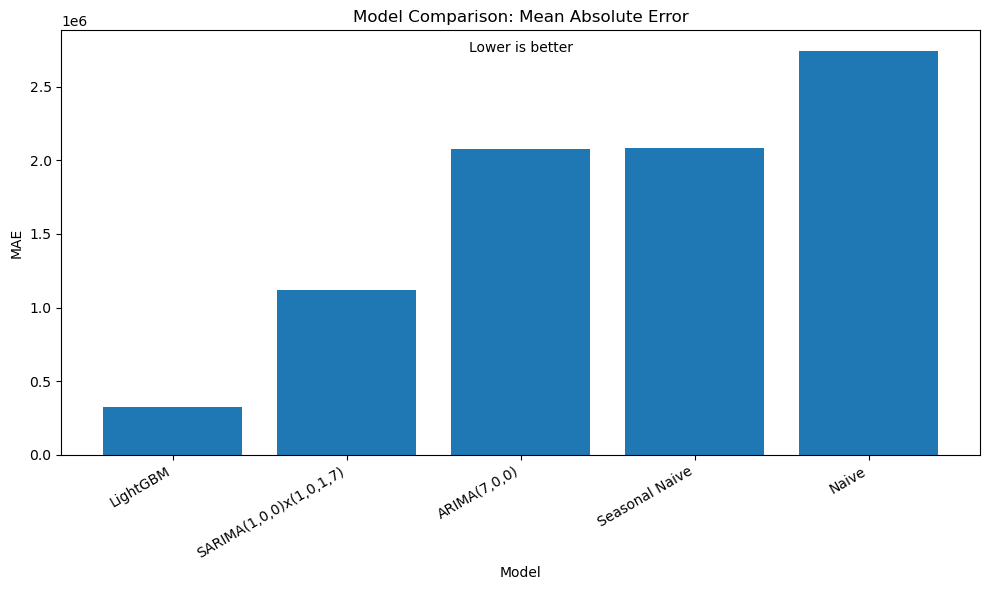

In [33]:
# Sort models by MAE for easier comparison
mae_comparison = model_results.sort_values("MAE")

plt.figure(figsize=(10, 6))
plt.bar(
    mae_comparison["Model"],
    mae_comparison["MAE"]
)
plt.text(
    0.5,
    0.95,
    "Lower is better",
    transform=plt.gca().transAxes,
    ha="center"
)

plt.title("Model Comparison: Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

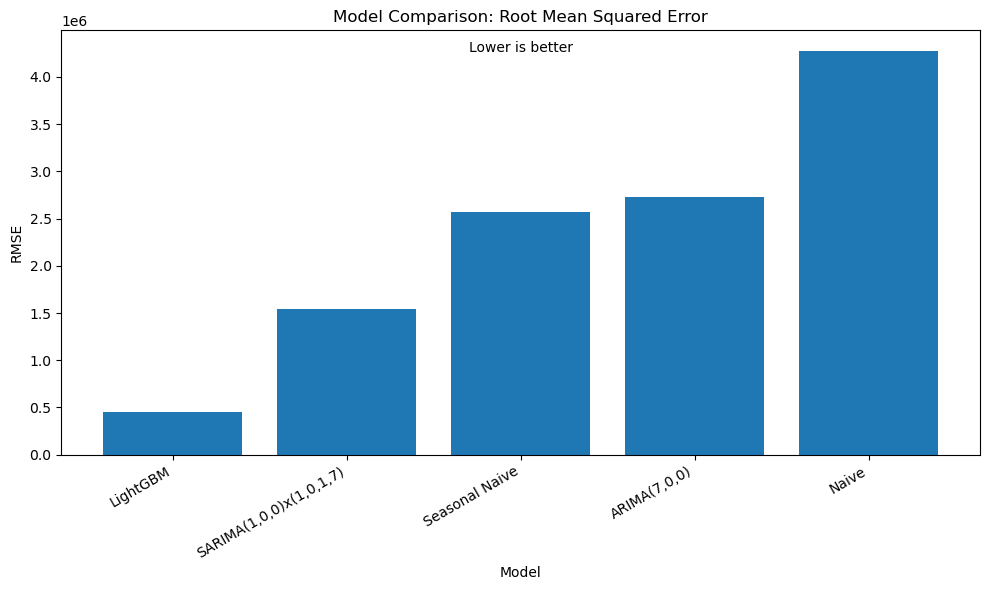

In [34]:
# Sort models by RMSE for easier comparison
rmse_comparison = model_results.sort_values("RMSE")

plt.figure(figsize=(10, 6))
plt.bar(
    rmse_comparison["Model"],
    rmse_comparison["RMSE"]
)
plt.text(
    0.5,
    0.95,
    "Lower is better",
    transform=plt.gca().transAxes,
    ha="center"
)

plt.title("Model Comparison: Root Mean Squared Error")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Interpretation

The MAE and RMSE visualizations show a clear difference in forecasting performance across the evaluated models.

LightGBM produced the lowest error on both metrics, followed by the final SARIMA model.

The Naive model produced the highest errors, while Seasonal Naive and ARIMA showed moderate improvements. The results indicate that explicitly modeling weekly seasonality improved classical forecasting performance, while LightGBM achieved the strongest overall performance on the shared 60-day holdout period.

## 6. Final Model Selection

Based on the evaluation results, LightGBM was selected as the final forecasting model.

LightGBM achieved the lowest error on both evaluation metrics:

- **MAE:** 323,834.04
- **RMSE:** 451,188.96

Compared with the best classical model, SARIMA(1,0,0)x(1,0,1,7), LightGBM reduced MAE by **71.15%** and RMSE by **70.71%** on the shared 60-day holdout period.

Therefore, LightGBM is selected as the strongest-performing model among those evaluated for this forecasting task.

## 7. Conclusion

This notebook compared the forecasting models developed in Phase 2 and Phase 3 using the same aggregated daily sales target, chronological test period, and evaluation metrics.

Among the classical models, SARIMA(1,0,0)x(1,0,1,7) achieved the strongest performance:

| Metric | SARIMA | LightGBM |
|---|---:|---:|
| MAE | 1,122,513 | 323,834 |
| RMSE | 1,540,606 | 451,189 |

LightGBM achieved the lowest MAE and RMSE of all evaluated models. Compared with SARIMA, it reduced MAE by 71.15% and RMSE by 70.71% on the shared 60-day holdout period.

Based on this evaluation, LightGBM was selected as the final forecasting model for this project.

